# Historical Earthquake Database: Statistical Overview

This notebook provides a concise, reproducible statistical overview of the CSV files in the repository. It uses relative paths and can be run either from the repository root or from the `python` directory.

**Requirements:** Python 3, pandas, and matplotlib.

This notebook and its documentation were developed with assistance from AI tools. All scientific interpretations and final decisions were reviewed and approved by the author.


## 1. Setup & data loading

In [1]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Locate the data directory whether the notebook is run from the repository root
# or directly from the python directory.
candidate_dirs = [Path("data"), Path("../data")]
DATA_DIR = next((path.resolve() for path in candidate_dirs if path.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("Could not locate the data directory. Run the notebook from the repository root or the python directory.")

FILES = [
    "a_sites_geo.csv",
    "v_damage_dst_reliable.csv",
    "v_damage_jerusalem.csv",
    "v_env_effects_dst_reliable.csv",
    "v_events_dst_doubtful.csv",
    "v_events_dst_reliable.csv",
    "v_events_dst_reliable_damaging.csv",
    "v_events_dst_reliable_damaging_destructive.csv",
    "v_events_off_dst_reliable.csv",
]

dfs = {}
for file in FILES:
    path = DATA_DIR / file
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")
    dfs[file] = pd.read_csv(path)
    print(f"Loaded {file}: {dfs[file].shape[0]:,} rows × {dfs[file].shape[1]:,} columns")


Loaded a_sites_geo.csv: 1,001 rows × 9 columns
Loaded v_damage_dst_reliable.csv: 1,481 rows × 23 columns
Loaded v_damage_jerusalem.csv: 62 rows × 5 columns
Loaded v_env_effects_dst_reliable.csv: 167 rows × 16 columns
Loaded v_events_dst_doubtful.csv: 134 rows × 25 columns
Loaded v_events_dst_reliable.csv: 373 rows × 25 columns
Loaded v_events_dst_reliable_damaging.csv: 236 rows × 27 columns
Loaded v_events_dst_reliable_damaging_destructive.csv: 28 rows × 27 columns
Loaded v_events_off_dst_reliable.csv: 73 rows × 25 columns


## 2. Helper functions

In [3]:
def overview_table(df):
    return pd.DataFrame({
        "rows": [len(df)],
        "columns": [df.shape[1]],
        "duplicate_rows": [df.duplicated().sum()],
        "total_missing_values": [int(df.isna().sum().sum())],
        "percent_missing_values": [round(df.isna().sum().sum() / (df.shape[0] * df.shape[1]) * 100, 2) 
                                   if df.size else 0],
    })

In [4]:
def missing_values_table(df):
    out = pd.DataFrame({
        "column": df.columns,
        "missing_count": df.isna().sum().values,
        "missing_percent": (df.isna().mean().values * 100).round(2),
        "dtype": [str(t) for t in df.dtypes.values],
    })
    return out.sort_values("missing_percent", ascending=False)

In [5]:
def add_century(df, date_col="Numeric_Date"):
    out = df.copy()
    if date_col in out.columns:
        dates = pd.to_numeric(out[date_col], errors="coerce")
        out["Century"] = ((dates // 100) + 1).astype("Int64")
    return out

In [6]:
def plot_bar_counts(df, column, title=None, top_n=20):
    if column not in df.columns:
        print(f"Column not found: {column}")
        return
    counts = df[column].value_counts(dropna=False).head(top_n)
    ax = counts.plot(kind="bar", color='orange', edgecolor='black', figsize=(10, 4))
    ax.set_title(title or f"Counts by {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()

In [7]:
def plot_hist(df, column, title=None, bins=20):
    if column not in df.columns:
        print(f"Column not found: {column}")
        return
    values = pd.to_numeric(df[column], errors="coerce").dropna()
    if values.empty:
        print(f"No numeric values available in {column}")
        return
    ax = values.plot(kind="hist", color='orange', edgecolor='black', bins=bins, figsize=(8, 4))
    ax.set_title(title or f"Distribution of {column}")
    ax.set_xlabel(column)
    plt.tight_layout()
    plt.show()

In [8]:
def plot_spatial(df, x_col="POINT_X", y_col="POINT_Y", title="Spatial distribution"):
    if x_col not in df.columns or y_col not in df.columns:
        print(f"Coordinate columns not found: {x_col}, {y_col}")
        return
    x = pd.to_numeric(df[x_col], errors="coerce")
    y = pd.to_numeric(df[y_col], errors="coerce")
    valid = x.notna() & y.notna()
    if valid.sum() == 0:
        print("No valid coordinates available.")
        return
    plt.figure(figsize=(7, 7))
    plt.scatter(x[valid], y[valid], s=10, c='red', marker='o', alpha=0.7)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [9]:
def plot_temporal_by_century(df, date_col="Numeric_Date", title="Records by century"):
    if date_col not in df.columns:
        print(f"Date column not found: {date_col}")
        return
    temp = add_century(df, date_col)
    if "Century" not in temp.columns:
        return
    counts = temp["Century"].value_counts().sort_index()
    ax = counts.plot(kind="bar", color='orange', edgecolor='black', figsize=(12, 4))
    ax.set_title(title)
    ax.set_xlabel("Century")
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()

In [10]:
def numeric_summary(df, columns):
    existing = [c for c in columns if c in df.columns]
    if not existing:
        return pd.DataFrame()
    return df[existing].apply(pd.to_numeric, errors="coerce").describe().T

## Sites (gazetteer-like)

**File:** `a_sites_geo.csv`

This section summarizes the master site gazetteer. The focus is on coordinate completeness, elevation values, and the spatial distribution of sites.

In [11]:
file = "a_sites_geo.csv"
df = dfs[file]

display(overview_table(df))

,rows,columns,duplicate_rows,total_missing_values,percent_missing_values
0,1001,9,0,1331,14.77


In [12]:
display(df.head())

,OBJECTID,Id,SITE_NAME,S_NAME,POINT_X,POINT_Y,REMARKS,POINT_Z,GlobalID
0,265,14215,Jiftlik,Jiftlik,35.4700,32.1400,NaN,0.0,4538FD33-4E56-4806-8737-00337BF3BF61
1,472,14518,Araplar,Araplar,36.4300,36.7400,NaN,0.0,78A0DBBA-8F0B-4563-8BD1-0071A0259B79
2,803,20033,Ein Hanasiv,NaN,29.7516,33.6797,NaN,NaN,8FE39665-130C-4E8C-A6AF-00754B0996CA
3,69,13309,Mugar (U),Mugar (U),35.5100,33.0400,NaN,0.0,A7E7E1DD-A3C9-4C14-B403-011751AA7F3B
4,789,20019,Augustopolis in Palaestina,NaN,29.7516,33.6797,NaN,NaN,9DA633B9-74E8-4E30-9B31-021385BBEF33


In [13]:
display(missing_values_table(df).head(15))

,column,missing_count,missing_percent,dtype
6,REMARKS,839,83.82,object
3,S_NAME,247,24.68,object
7,POINT_Z,241,24.08,float64
5,POINT_Y,2,0.20,float64
4,POINT_X,2,0.20,float64
0,OBJECTID,0,0.00,int64
2,SITE_NAME,0,0.00,object
1,Id,0,0.00,int64
8,GlobalID,0,0.00,object


In [14]:
display(numeric_summary(df, ["POINT_X", "POINT_Y", "POINT_Z"]))
print("Unique site names:", df["SITE_NAME"].nunique() 
      if "SITE_NAME" in df.columns else "Column SITE_NAME not found")

,count,mean,std,min,25%,50%,75%,max
POINT_X,999.0,33.918522,2.747098,20.73,31.350,34.95,35.4800,44.52
POINT_Y,999.0,32.816380,1.878663,23.42,31.685,33.05,33.6797,41.02
POINT_Z,760.0,0.000000,0.000000,0.00,0.000,0.00,0.0000,0.00


Unique site names: 990


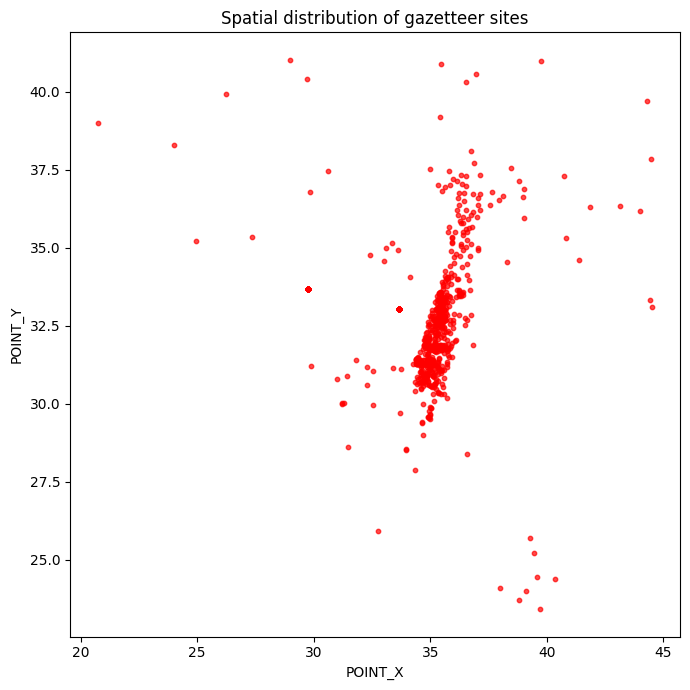

In [15]:
plot_spatial(df, "POINT_X", "POINT_Y", "Spatial distribution of gazetteer sites")

## Reliable DST damage

**File:** `v_damage_dst_reliable.csv`

This section summarizes reliable damage observations associated with earthquakes in the Dead Sea Transform region. The focus is on affected sites, damage levels, casualties, and intensity estimates.

In [16]:
file = "v_damage_dst_reliable.csv"
df = dfs[file]

display(overview_table(df))

,rows,columns,duplicate_rows,total_missing_values,percent_missing_values
0,1481,23,3,10088,29.62


In [17]:
display(df.head())

,Order_Date,Full_Date,Numeric_Date,Event_Type,Event_Mag,Rel,SITE_NAME,POINT_X,POINT_Y,Damage,Damage_Val,Causalties_Val,EMS98_Value,EMS98_Num,MSK_Value,MSK_Num,Other_Intensity,Total_Bld,Damaged_Bld,Total_Pop,Casualties,Injuries,Description
0,-1,Unknown,-10000.0,U,NaN,Mr,Tel Ateret,35.627735,33.004631,4,Heavy,U,9-10,9.5,U,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,Following excavations in Tell Ateret of EMK. T...
1,1,c. 8.4–9.0 ka BCE,-8000.0,U,NaN,Mr,Qiryat Shemona-EEA (A),35.550000,33.190000,-1,U,U,U,-1.0,U,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,KKW have identified rock falls close to Qiryat...
2,8,~2900 BCE,2900.0,U,NaN,Dr,Tel el-Saiidiyeh,35.570000,32.310000,3,Moderate,U,8,8.0,U,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,FR following Tubb 1988
3,8,~2900 BCE,2900.0,U,NaN,Dr,Tel el-Fukhar,35.952770,32.680746,3,Moderate,U,8,8.0,U,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,FR following Savage 2003
4,11,c.2100-1700 BCE,-1900.0,S,NaN,Dr,Tel Abu en-Ni’aj,35.565725,32.426168,3,Moderate,U,8,8.0,U,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,FR suggest potential damage due to an earthqua...


In [18]:
display(missing_values_table(df).head(15))

,column,missing_count,missing_percent,dtype
17,Total_Bld,1469,99.19,object
19,Total_Pop,1467,99.05,object
16,Other_Intensity,1451,97.97,object
21,Injuries,1445,97.57,object
18,Damaged_Bld,1427,96.35,object
20,Casualties,1394,94.13,object
22,Description,735,49.63,object
4,Event_Mag,460,31.06,float64
10,Damage_Val,232,15.67,object
7,POINT_X,4,0.27,float64


Unique affected sites: 547


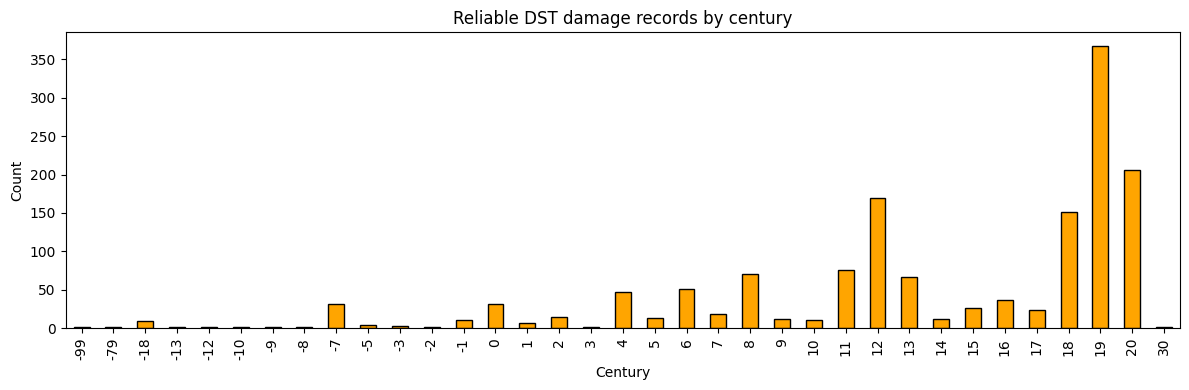

In [19]:
print("Unique affected sites:", df["SITE_NAME"].nunique() if "SITE_NAME" in df.columns 
      else "Column SITE_NAME not found")
plot_temporal_by_century(df, "Numeric_Date", "Reliable DST damage records by century")


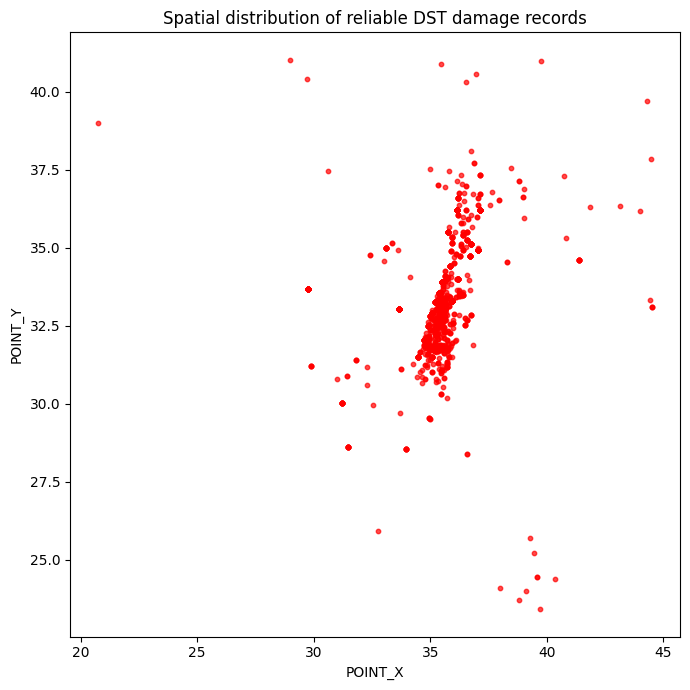

In [20]:
plot_spatial(df, "POINT_X", "POINT_Y", "Spatial distribution of reliable DST damage records")


In [21]:
display(numeric_summary(df, ["Event_Mag", "Damage_Val", "Causalties_Val", "EMS98_Num", "MSK_Num", 
                             "Total_Bld", "Damaged_Bld", "Total_Pop", "Casualties", "Injuries"]))

,count,mean,std,min,25%,50%,75%,max
Event_Mag,1021.0,6.549295,0.937011,4.5,6.25,6.7,7.2,7.83
Damage_Val,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Causalties_Val,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EMS98_Num,1481.0,1.350439,3.696933,-1.0,-1.00,-1.0,5.0,11.00
MSK_Num,1481.0,-0.289332,2.251242,-1.0,-1.00,-1.0,-1.0,9.50
Total_Bld,10.0,200.800000,565.371225,1.0,1.00,1.0,1.0,1800.00
Damaged_Bld,45.0,140.422222,283.514749,1.0,1.00,14.0,150.0,1210.00
Total_Pop,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Casualties,65.0,3163.261538,21343.802177,1.0,4.00,12.0,50.0,170000.00
Injuries,21.0,25.142857,54.661948,1.0,3.00,6.0,20.0,250.00


## Jerusalem damage

**File:** `v_damage_jerusalem.csv`

This section summarizes historical earthquake damage reports for Jerusalem. The focus is on chronology, reported damage degree, reliability, and descriptive record completeness.

In [22]:
file = "v_damage_jerusalem.csv"
df = dfs[file]

display(overview_table(df))

,rows,columns,duplicate_rows,total_missing_values,percent_missing_values
0,62,5,0,36,11.61


In [23]:
display(df.head())

,Numeric_Date,Full_Date,Degree,Reliablility,Description
0,-760.0,c.760-750 BCE,3,2,Though Jerusalem is not specifically mentioned...
1,-92.0,92 Feb 28 BCE,3,5,AM (p.96) and KA2 question the entry in BM5 co...
2,-65.0,c.65 BCE,3,5,AM ollowing the Babylonian Talmud. Baba Kama: ...
3,-31.0,31 early spring BCE,3,5,AM following AAT
4,33.0,33,0,4,The testimony of St. Mathwre is not clear and ...


In [24]:
display(missing_values_table(df).head(15))

,column,missing_count,missing_percent,dtype
4,Description,36,58.06,object
0,Numeric_Date,0,0.00,float64
1,Full_Date,0,0.00,object
2,Degree,0,0.00,int64
3,Reliablility,0,0.00,int64


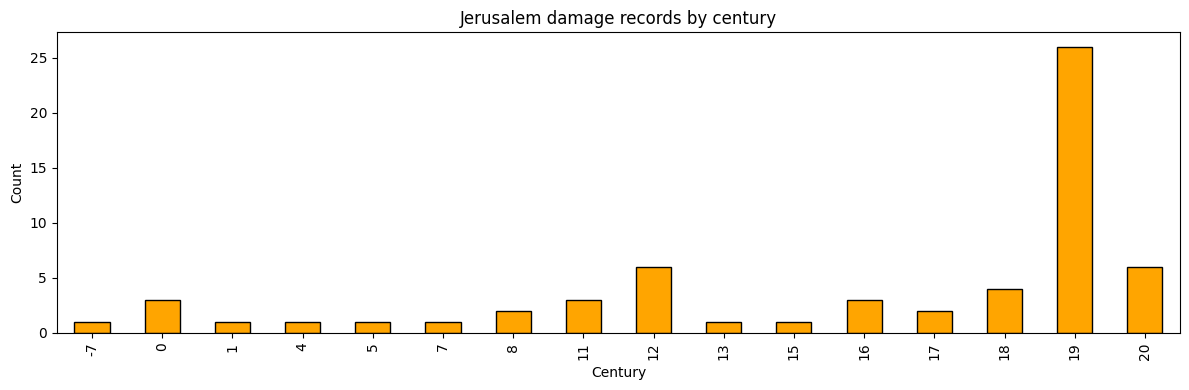

In [25]:
plot_temporal_by_century(df, "Numeric_Date", "Jerusalem damage records by century")

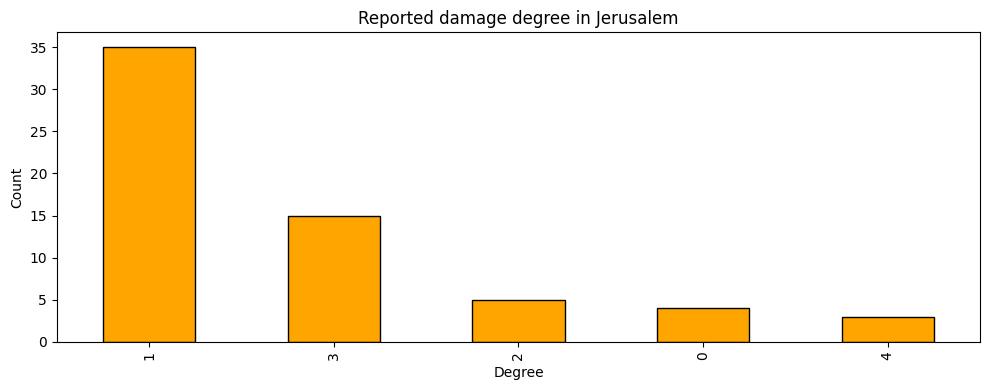

In [26]:
plot_bar_counts(df, "Degree", "Reported damage degree in Jerusalem", top_n=20)


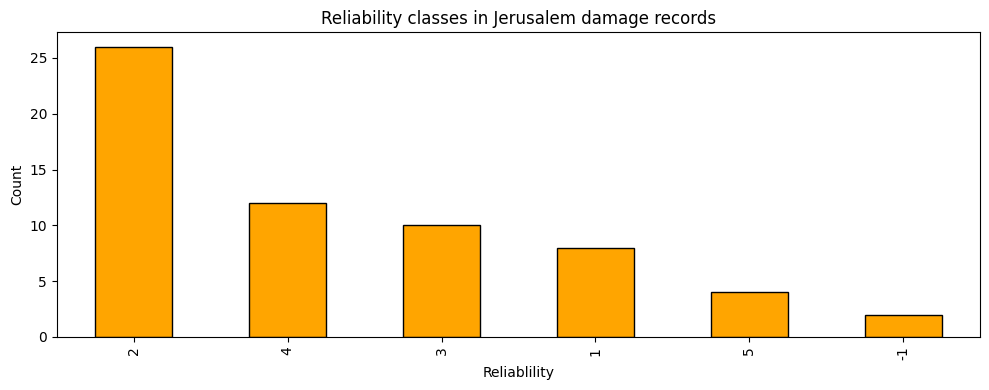

In [27]:
plot_bar_counts(df, "Reliablility", "Reliability classes in Jerusalem damage records", top_n=20)

In [28]:
display(numeric_summary(df, ["Numeric_Date"]))

,count,mean,std,min,25%,50%,75%,max
Numeric_Date,62.0,1442.143548,640.885352,-760.0,1114.75,1819.5,1873.275,1927.0


## Reliable DST environmental effects

**File:** `v_env_effects_dst_reliable.csv`

This section summarizes reliable environmental effects associated with DST earthquakes. The focus is on effect categories, environmental effect values, ESI values, and spatial distribution.

In [29]:
file = "v_env_effects_dst_reliable.csv"
df = dfs[file]

display(overview_table(df))

,rows,columns,duplicate_rows,total_missing_values,percent_missing_values
0,167,16,0,84,3.14


In [30]:
display(df.head())

,Order_Date,Full_Date,Numeric_Date,Event_Type,Event_Mag,SITE_NAME,POINT_X,POINT_Y,Rel,Env_Eff,Env_Eff_Val,Env_Eff2,Category,Description,ESI_Val,ESI_Num
0,-1,Unknown,-10000.0,U,NaN,Tel Ateret,35.627735,33.004631,Moderate,GB,"Ground breakage, fissures",-1,Ground breakage,Following excavations in Tell Ateret of EMK. T...,10 - VERY DESTRUCTIVE,10.0
1,1,c. 8.4–9.0 ka BCE,-8000.0,U,NaN,Qiryat Shemona-EEA (A),35.550000,33.190000,Moderate,RF,Rock falls,-1,Other,KKW have identified rock falls close to Qiryat...,7-8,7.5
2,11,c.2100-1700 BCE,-1900.0,S,NaN,Qiryat Shemona-EEA (A),35.550000,33.190000,Moderate,RF,Rock falls,-1,Other,KKW suggest rock falls close to Qiryat Shemona...,7-8,7.5
3,17,980-830 BCE (Iron age ||A),-980.0,S,NaN,Tel Ateret,35.627735,33.004631,Moderate,GB,"Ground breakage, fissures",-1,Ground breakage,Following excavations in Tell Ateret of EMK,11 - DEVASTATING,11.0
4,19,c.760-750 BCE,-760.0,S,7.83,Qiryat Shemona-EEA (A),35.550000,33.190000,Moderate,RF,Rock falls,-1,Other,Dated rockfalls (after KKW),8 - HEAVILY DAMAGING,8.0


In [31]:
display(missing_values_table(df).head(15))

,column,missing_count,missing_percent,dtype
13,Description,48,28.74,object
4,Event_Mag,36,21.56,float64
2,Numeric_Date,0,0.00,float64
0,Order_Date,0,0.00,int64
3,Event_Type,0,0.00,object
5,SITE_NAME,0,0.00,object
6,POINT_X,0,0.00,float64
1,Full_Date,0,0.00,object
7,POINT_Y,0,0.00,float64
8,Rel,0,0.00,object


Unique affected sites: 120


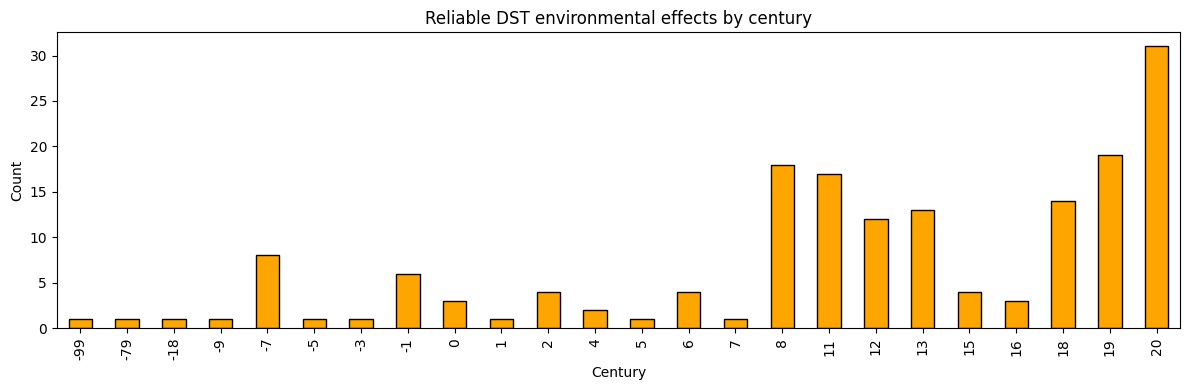

In [32]:
print("Unique affected sites:", df["SITE_NAME"].nunique() if "SITE_NAME" in df.columns else "Column SITE_NAME not found")
plot_temporal_by_century(df, "Numeric_Date", "Reliable DST environmental effects by century")


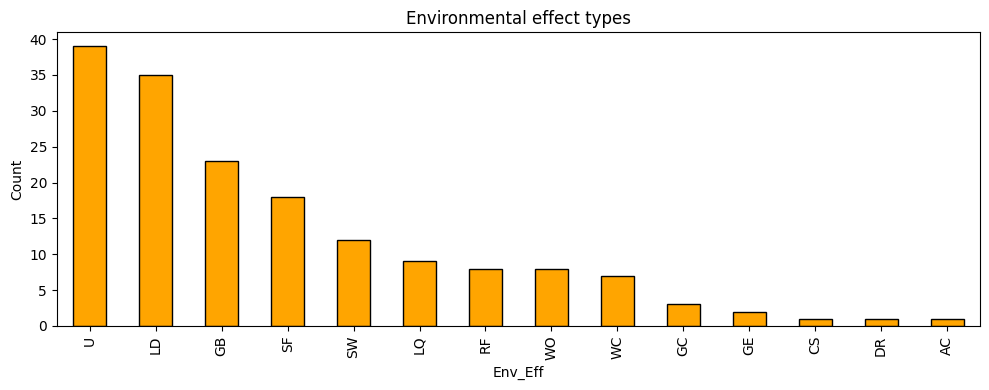

In [33]:
plot_bar_counts(df, "Env_Eff", "Environmental effect types", top_n=20)

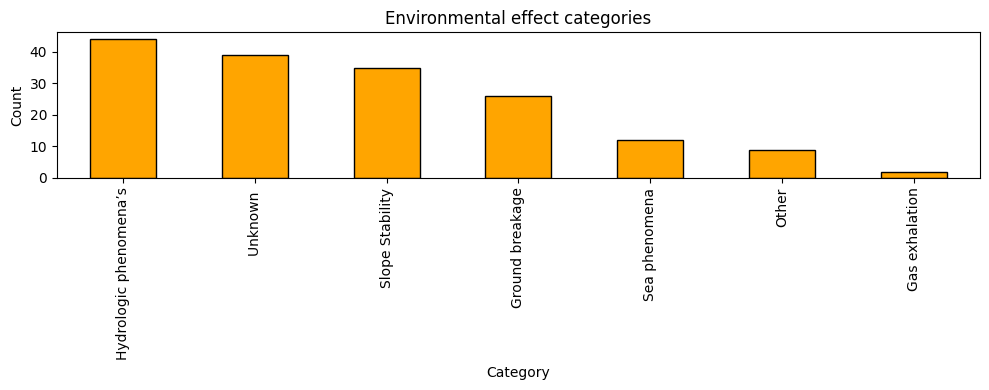

In [34]:
plot_bar_counts(df, "Category", "Environmental effect categories", top_n=20)

In [35]:
plot_hist(df, "Env_Eff_Val", "Environmental effect value distribution", bins=15)

No numeric values available in Env_Eff_Val


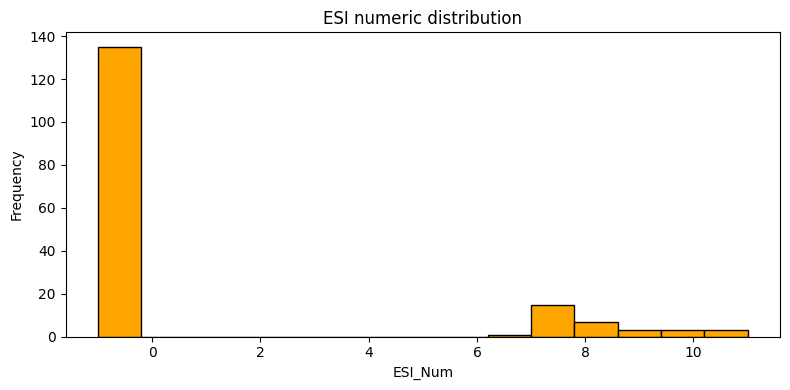

In [36]:
plot_hist(df, "ESI_Num", "ESI numeric distribution", bins=15)

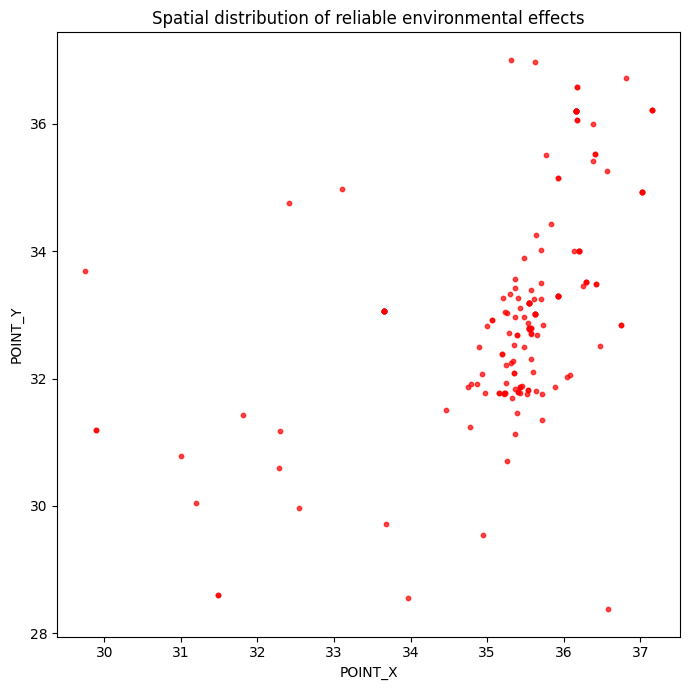

In [37]:
plot_spatial(df, "POINT_X", "POINT_Y", "Spatial distribution of reliable environmental effects")

In [38]:
display(numeric_summary(df, ["Event_Mag", "Env_Eff_Val", "ESI_Num"]))

,count,mean,std,min,25%,50%,75%,max
Event_Mag,131.0,6.963282,0.552422,4.5,6.275,7.2,7.3,7.83
Env_Eff_Val,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ESI_Num,167.0,0.763473,3.673749,-1.0,-1.000,-1.0,-1.0,11.00


## Doubtful DST events

**File:** `v_events_dst_doubtful.csv`

This section summarizes doubtful or weakly constrained earthquake events. The focus is on uncertainty, reliability classifications, chronology, and basic magnitude/intensity distributions.

In [39]:
file = "v_events_dst_doubtful.csv"
df = dfs[file]

display(overview_table(df))


,rows,columns,duplicate_rows,total_missing_values,percent_missing_values
0,134,25,0,837,24.99


In [40]:
display(df.head())

,Order_Date,Full_Date,Numeric_Date,Date_Uncertainty,Rel,Type,Size,Size_Val,Magnitude,Magnitude_Avg,Max_Intensity,Depth,Epi_X,Epi_Y,Region,Most_Damaged_Sites,Most_Damaged,MSRD_X,MSRD_Y,Tsunami,GII,Description,Historical_Reports,Ref,Evidence_Type
0,8,~2900 BCE,2900.0,NaN,Doubtful,U,-1,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,U,NaN,Unknown,33.650822,33.051288,0,0,FR relates damage to an event occurred in ~290...,NaN,FR,Archaeoseismic
1,8,~2900 BCE,2900.0,NaN,Doubtful,U,-1,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,U,NaN,Test,NaN,NaN,0,0,FR relates damage to an event occurred in ~290...,NaN,FR,Archaeoseismic
2,11,c.2100-1700 BCE,-1900.0,400,Poor,S,4,Strong,NaN,NaN,NaN,NaN,NaN,NaN,C,"Sodom, Judea",Sodom and Ghomorrah,35.500000,31.200000,0,1,"The claim that the destruction of Sodom, Gomor...",Secondary: Genesis ( 19.24-28; 29.23); Strabo...,AM; BEN;,Historical
3,12,c.1400 BCE,-1400.0,100,Poor,S,4,Strong,NaN,NaN,NaN,NaN,NaN,NaN,C,Jericho,Jericho,35.462647,31.860139,0,0,"The tumbling down of Jericho’s walls (Joshua, ...","Secondary: Joshua, 6.20-21: Bible, 1989",AM; BEN;,Historical
4,13,c.1365 BCE,-1365.0,10,Poor,S,4,Strong,NaN,NaN,NaN,NaN,NaN,NaN,N,Ugarit,Ugarit,35.800000,35.650000,1,0,The only historical reference refers to an eve...,Abimilki of Tyre to Amenophis IV (?),SDM; SAL2,Historical


In [41]:
display(missing_values_table(df).head(15))

,column,missing_count,missing_percent,dtype
8,Magnitude,134,100.00,float64
11,Depth,134,100.00,float64
13,Epi_Y,134,100.00,float64
12,Epi_X,134,100.00,float64
10,Max_Intensity,127,94.78,object
9,Magnitude_Avg,102,76.12,float64
22,Historical_Reports,42,31.34,object
21,Description,13,9.70,object
3,Date_Uncertainty,10,7.46,object
15,Most_Damaged_Sites,5,3.73,object


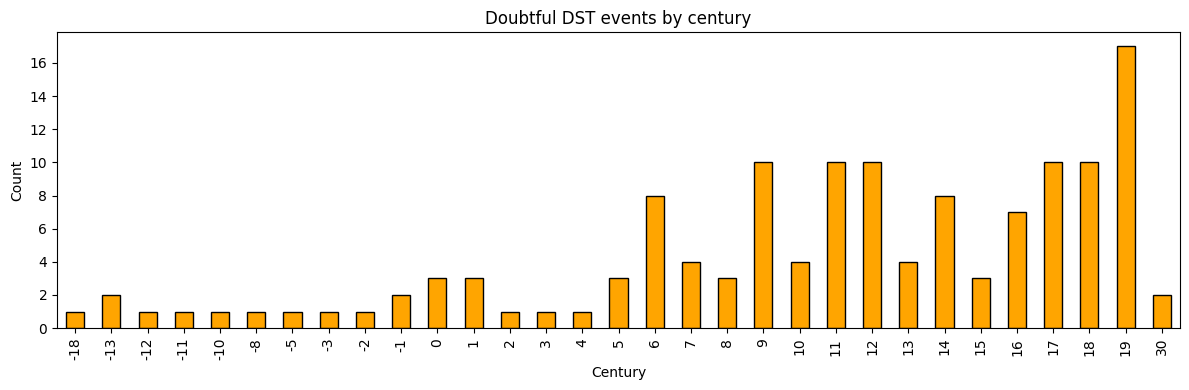

In [42]:
plot_temporal_by_century(df, "Numeric_Date", "Doubtful DST events by century")

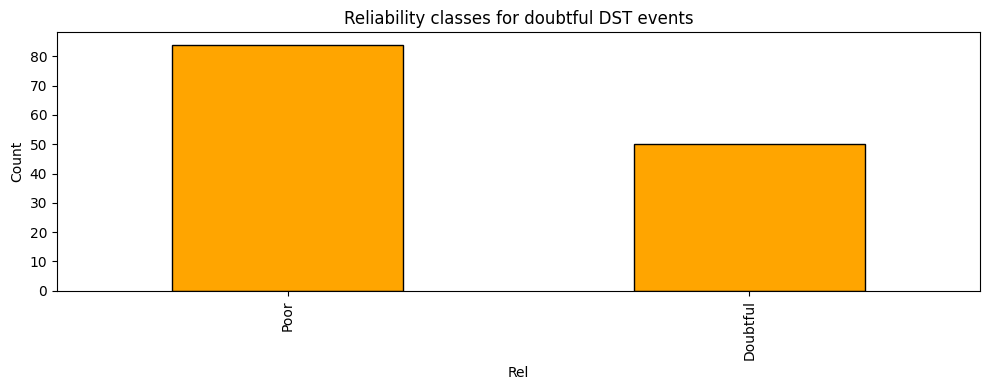

In [43]:
plot_bar_counts(df, "Rel", "Reliability classes for doubtful DST events", top_n=20)

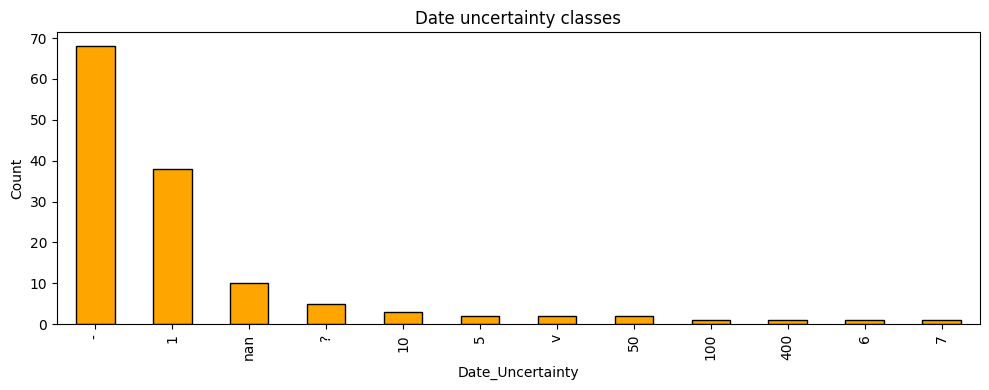

In [44]:
plot_bar_counts(df, "Date_Uncertainty", "Date uncertainty classes", top_n=20)

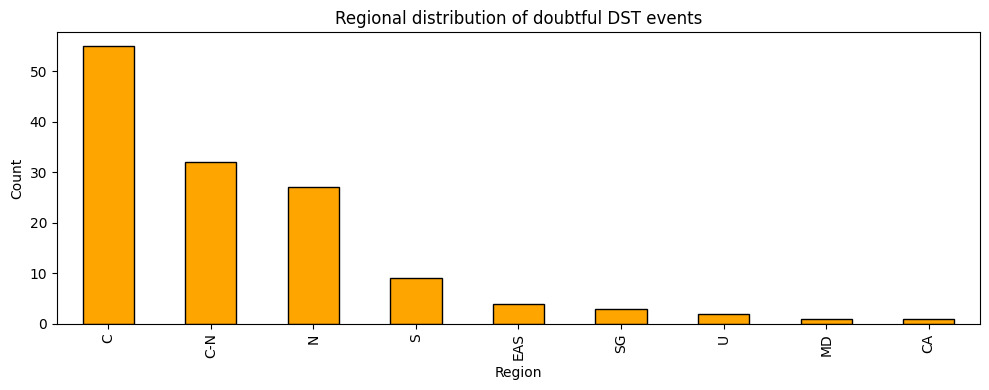

In [45]:
plot_bar_counts(df, "Region", "Regional distribution of doubtful DST events", top_n=20)

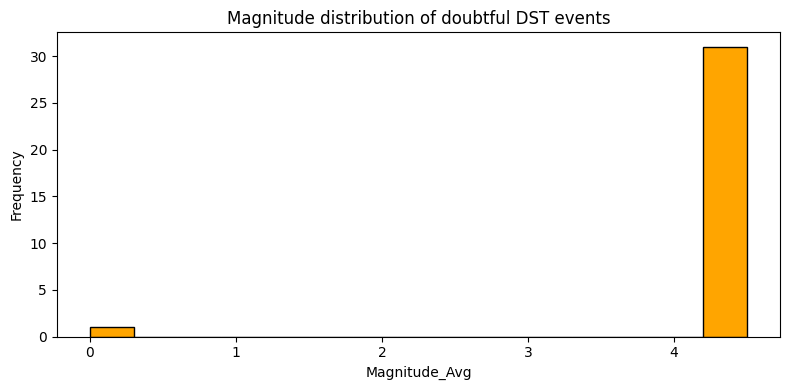

In [46]:
plot_hist(df, "Magnitude_Avg", "Magnitude distribution of doubtful DST events", bins=15)

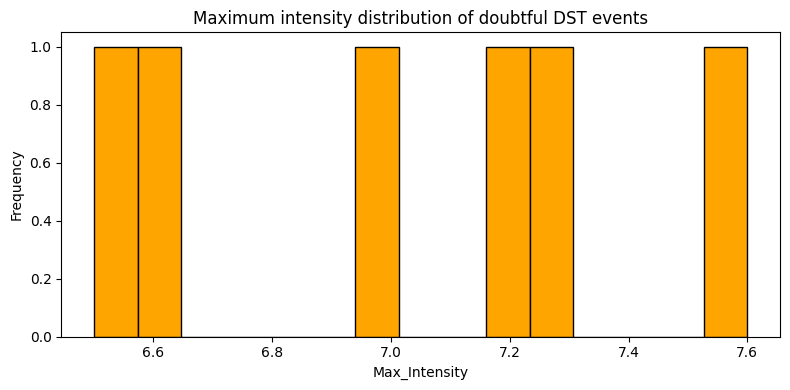

In [47]:
plot_hist(df, "Max_Intensity", "Maximum intensity distribution of doubtful DST events", bins=15)

In [48]:
display(numeric_summary(df, ["Magnitude", "Magnitude_Avg", "Max_Intensity", "Depth", "Epi_X", "Epi_Y"]))

,count,mean,std,min,25%,50%,75%,max
Magnitude,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Magnitude_Avg,32.0,4.359375,0.795495,0.0,4.5,4.5,4.500,4.5
Max_Intensity,6.0,7.033333,0.422690,6.5,6.7,7.1,7.275,7.6
Depth,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Epi_X,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Epi_Y,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Reliable DST events

**File:** `v_events_dst_reliable.csv`

This section summarizes the main reliable earthquake catalogue for the Dead Sea Transform region. The focus is on temporal coverage, magnitude/intensity distributions, regional attribution, and epicentral locations.

In [49]:
file = "v_events_dst_reliable.csv"
df = dfs[file]

display(overview_table(df))


,rows,columns,duplicate_rows,total_missing_values,percent_missing_values
0,373,25,0,1917,20.56


In [50]:
display(df.head())

,Order_Date,Full_Date,Numeric_Date,Date_Uncertainty,Rel,Type,Size,Size_Val,Magnitude,Magnitude_Avg,Max_Intensity,Depth,Epi_X,Epi_Y,Region,Most_Damaged_Sites,Most_Damaged,MSRD_X,MSRD_Y,Tsunami,GII,Description,Historical_Reports,Ref,Evidence_Type
0,-1,Unknown,-10000.0,NaN,Moderate,U,-1,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,U,NaN,Unknown,33.650822,33.051288,NaN,NaN,NaN,NaN,NaN,U
1,-1,Unknown,-10000.0,NaN,Moderate,U,-1,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,U,NaN,Test,NaN,NaN,NaN,NaN,NaN,NaN,NaN,U
2,1,c. 8.4–9.0 ka BCE,-8000.0,600,Moderate,U,4,Strong,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,Test,NaN,NaN,0.0,0.0,On the Yammunneh fault in Lebanon dated to 8.4...,NaN,DAKL,Paleoseismic & Archaeoseismic
3,1,c. 8.4–9.0 ka BCE,-8000.0,600,Moderate,U,4,Strong,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,Unknown,33.650822,33.051288,0.0,0.0,On the Yammunneh fault in Lebanon dated to 8.4...,NaN,DAKL,Paleoseismic & Archaeoseismic
4,2,c. 250 BCE,-250.0,10,High,S,4,Strong,NaN,NaN,NaN,NaN,0.0,0.0,C,Arad,Judea (A),35.350000,32.080000,0.0,0.0,Mid 3rd century BCE Earthquake at Arad. TEMPOR...,NaN,Herzog (2002),Paleoseismic & Archaeoseismic


In [51]:
display(missing_values_table(df).head(15))

,column,missing_count,missing_percent,dtype
10,Max_Intensity,361,96.78,object
11,Depth,310,83.11,float64
12,Epi_X,288,77.21,float64
13,Epi_Y,288,77.21,float64
8,Magnitude,252,67.56,object
9,Magnitude_Avg,175,46.92,float64
22,Historical_Reports,119,31.90,object
21,Description,91,24.40,object
15,Most_Damaged_Sites,10,2.68,object
3,Date_Uncertainty,8,2.14,object


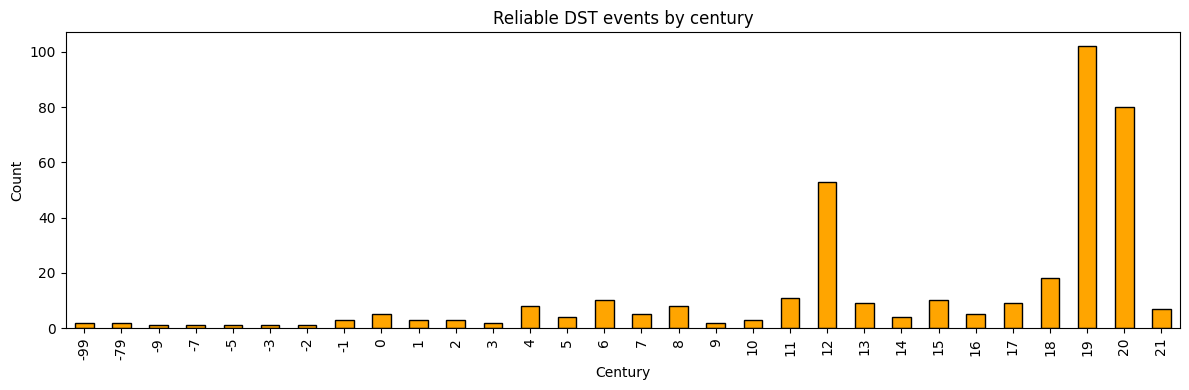

In [52]:
plot_temporal_by_century(df, "Numeric_Date", "Reliable DST events by century")


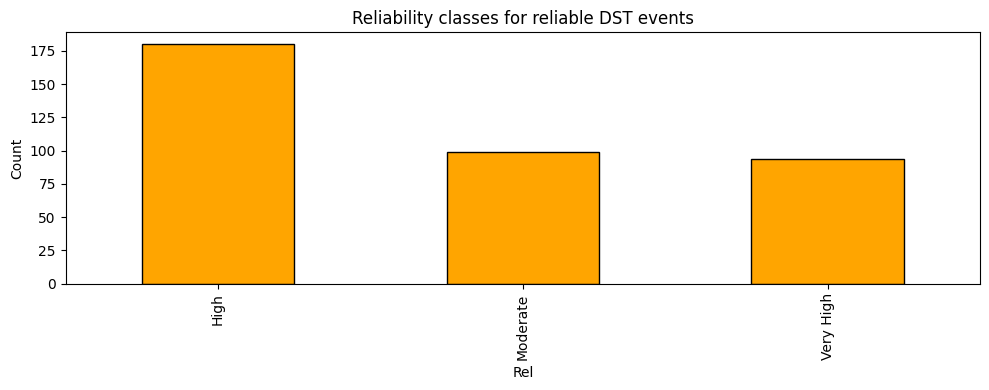

In [53]:
plot_bar_counts(df, "Rel", "Reliability classes for reliable DST events", top_n=20)

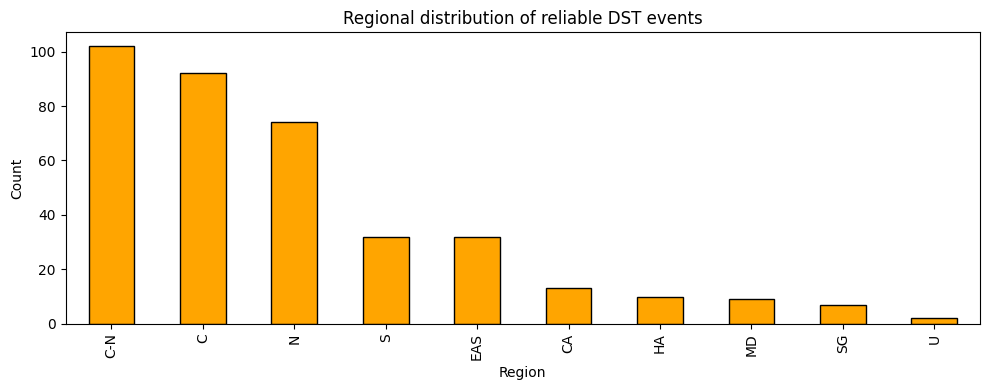

In [54]:
plot_bar_counts(df, "Region", "Regional distribution of reliable DST events", top_n=20)

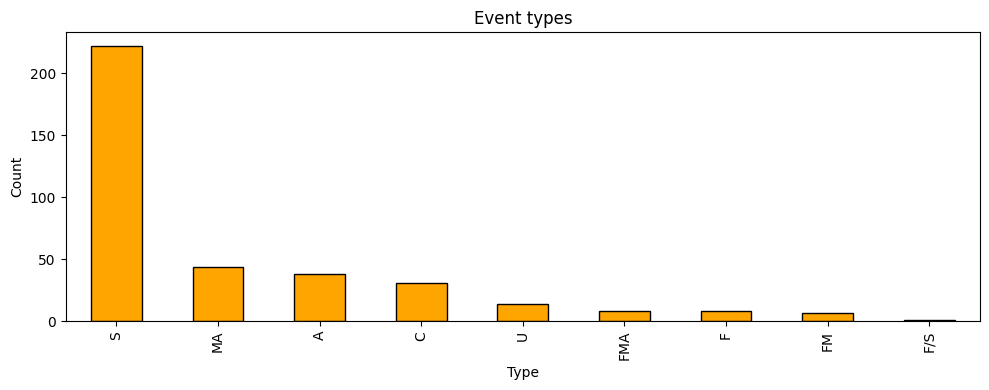

In [55]:
plot_bar_counts(df, "Type", "Event types", top_n=20)

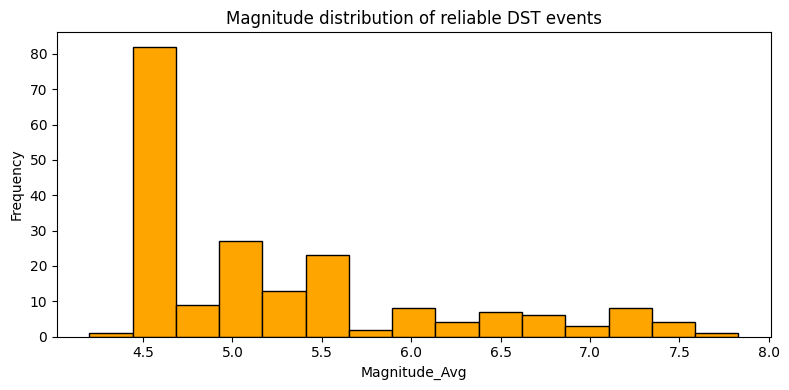

In [56]:
plot_hist(df, "Magnitude_Avg", "Magnitude distribution of reliable DST events", bins=15)

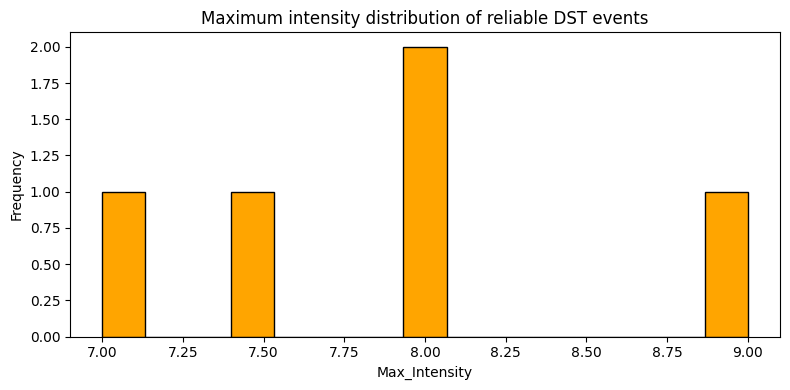

In [57]:
plot_hist(df, "Max_Intensity", "Maximum intensity distribution of reliable DST events", bins=15)

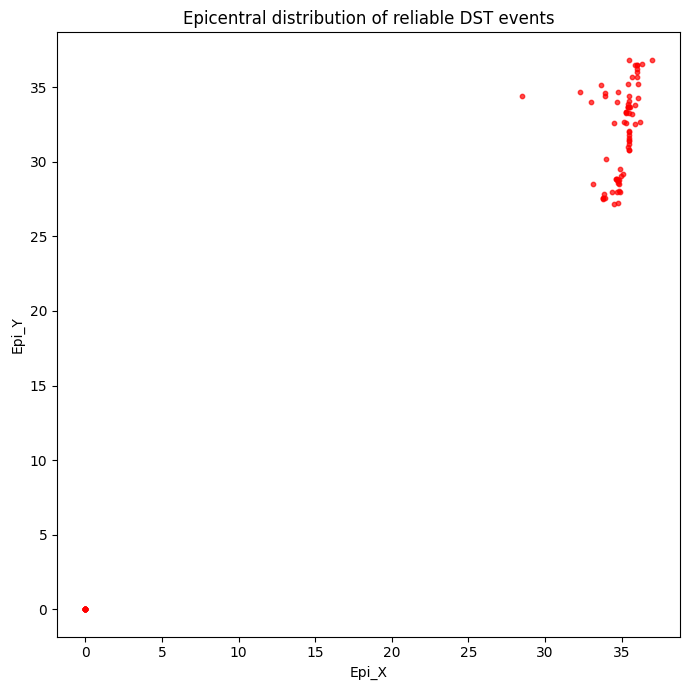

In [58]:
plot_spatial(df, "Epi_X", "Epi_Y", "Epicentral distribution of reliable DST events")


In [59]:
display(numeric_summary(df, ["Magnitude", "Magnitude_Avg", "Max_Intensity", "Depth", "Epi_X", "Epi_Y"]))

,count,mean,std,min,25%,50%,75%,max
Magnitude,3.0,5.133333,0.230940,5.0,5.00,5.00,5.20,5.40
Magnitude_Avg,198.0,5.228687,0.878267,4.2,4.50,5.00,5.50,7.83
Max_Intensity,5.0,7.900000,0.741620,7.0,7.50,8.00,8.00,9.00
Depth,63.0,13.619048,8.945045,0.0,10.00,10.00,15.00,36.00
Epi_X,85.0,30.447765,11.856008,0.0,33.92,34.99,35.50,36.96
Epi_Y,85.0,27.924235,11.178223,0.0,28.04,31.80,34.04,36.85


## Reliable damaging DST events

**File:** `v_events_dst_reliable_damaging.csv`

This section summarizes reliable DST earthquakes with documented damage. The focus is on the subset of events that produced damage, their maximum observed damage, and their temporal/spatial distribution.

In [60]:

file = "v_events_dst_reliable_damaging.csv"
df = dfs[file]

display(overview_table(df))


,rows,columns,duplicate_rows,total_missing_values,percent_missing_values
0,236,27,0,1279,20.07


In [61]:
display(df.head())

,Order_Date,Full_Date,Numeric_Date,Date_Uncertainty,Rel,Type,Size,Size_Val,Magnitude,Magnitude_Avg,Max_Intensity,Depth,Epi_X,Epi_Y,Region,Most_Damaged_Sites,Most_Damaged,MSRD_X,MSRD_Y,Tsunami,GII,Description,Historical_Reports,Ref,Evidence_Type,C_Damage,Max_Damage
0,1,c. 8.4–9.0 ka BCE,-8000.0,600,Moderate,U,4,Strong,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,Test,NaN,NaN,0,0,On the Yammunneh fault in Lebanon dated to 8.4...,NaN,DAKL,Paleoseismic & Archaeoseismic,1,-1
1,1,c. 8.4–9.0 ka BCE,-8000.0,600,Moderate,U,4,Strong,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,Unknown,33.650822,33.051288,0,0,On the Yammunneh fault in Lebanon dated to 8.4...,NaN,DAKL,Paleoseismic & Archaeoseismic,1,-1
2,17,980-830 BCE (Iron age ||A),-980.0,150,Moderate,S,4,Strong,NaN,NaN,NaN,NaN,0.0,0.0,C-N,Tell Ateret,Tel Ateret,35.627735,33.004631,0,0,EMK describes an earthquake thet ruptured Tell...,NaN,EMK,Paleoseismic & Archaeoseismic,2,4
3,19,c.760-750 BCE,-760.0,10,High,S,4,Strong,7.8-8.2 (AUS); 8.2 (BM5); 7.3 (BM),7.83,8,NaN,NaN,NaN,C,Judaea,Judea (A),35.350000,32.080000,0,1,Damaging event during mid-8th century BCE. Amo...,Contemporary: Amos 1.1; 3.14-15; 7.13; 9.5\r\n...,AM; GCT; AM2; SAL; SAL2; WALE; BEN; ZIL2; AUS;...,Historical & Paleoseimic/Archaeoseimic,31,4
4,21,525 BCE,-525.0,-,Moderate,S,4,Strong,NaN,NaN,NaN,NaN,NaN,NaN,C-N,Palestine,Dead Sea East (A),35.570000,31.620000,1,1,"KA2 pointed out the entry citation by PLKO, BM...",NaN,BM; PLKO; SI; SDM; KA2; GII; MIG; KAG,Paleoseismic & Archaeoseismic,3,3


In [62]:
display(missing_values_table(df).head(15))

,column,missing_count,missing_percent,dtype
11,Depth,231,97.88,float64
12,Epi_X,225,95.34,float64
13,Epi_Y,225,95.34,float64
10,Max_Intensity,224,94.92,object
8,Magnitude,188,79.66,object
9,Magnitude_Avg,121,51.27,float64
21,Description,34,14.41,object
22,Historical_Reports,23,9.75,object
23,Ref,3,1.27,object
15,Most_Damaged_Sites,2,0.85,object


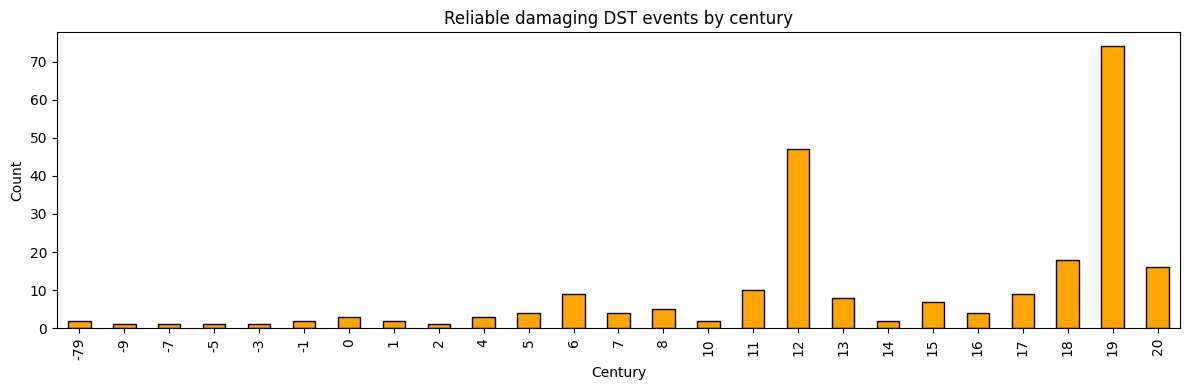

In [63]:
plot_temporal_by_century(df, "Numeric_Date", "Reliable damaging DST events by century")


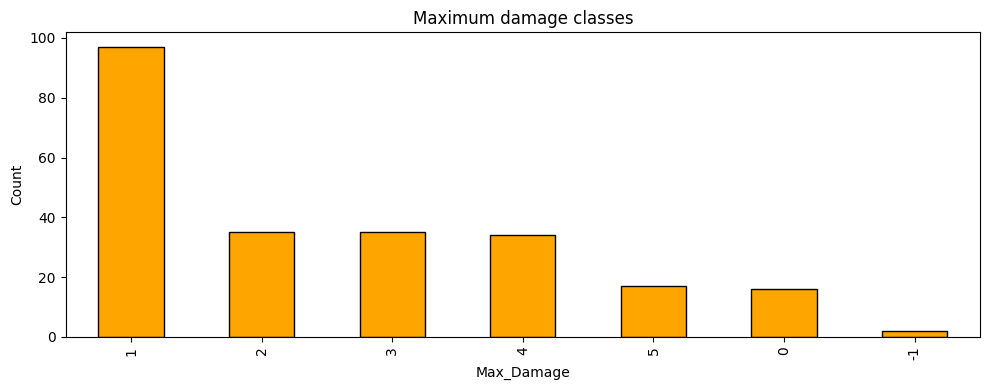

In [64]:
plot_bar_counts(df, "Max_Damage", "Maximum damage classes", top_n=20)

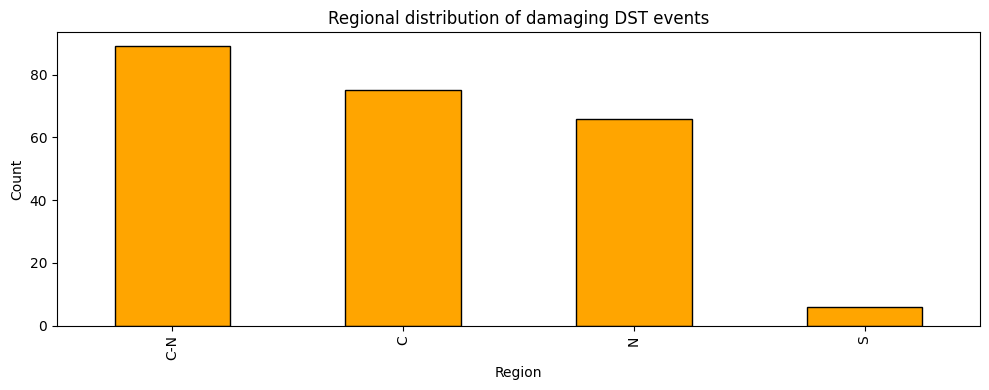

In [65]:
plot_bar_counts(df, "Region", "Regional distribution of damaging DST events", top_n=20)

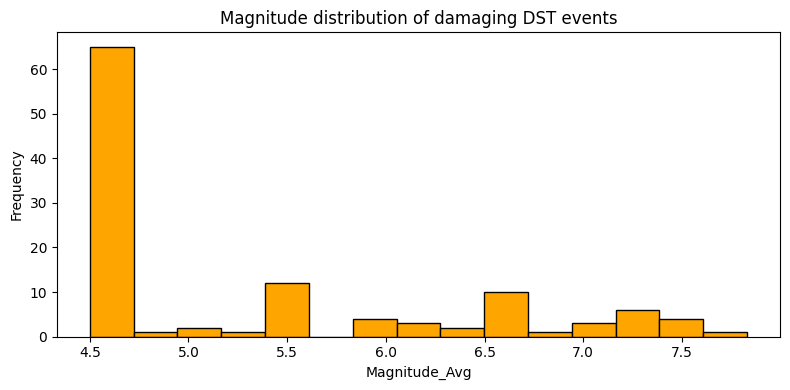

In [66]:
plot_hist(df, "Magnitude_Avg", "Magnitude distribution of damaging DST events", bins=15)

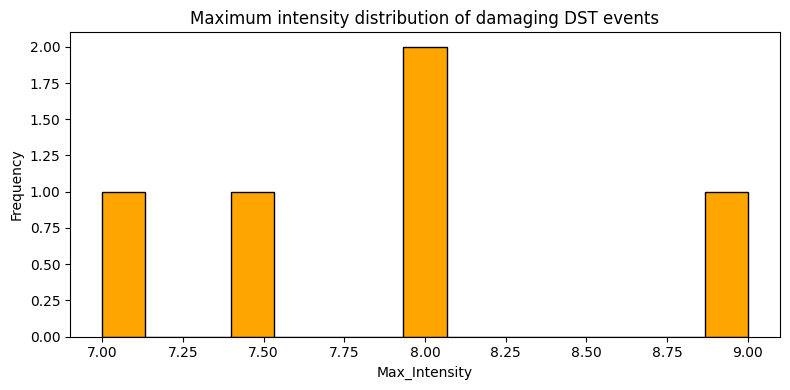

In [67]:
plot_hist(df, "Max_Intensity", "Maximum intensity distribution of damaging DST events", bins=15)

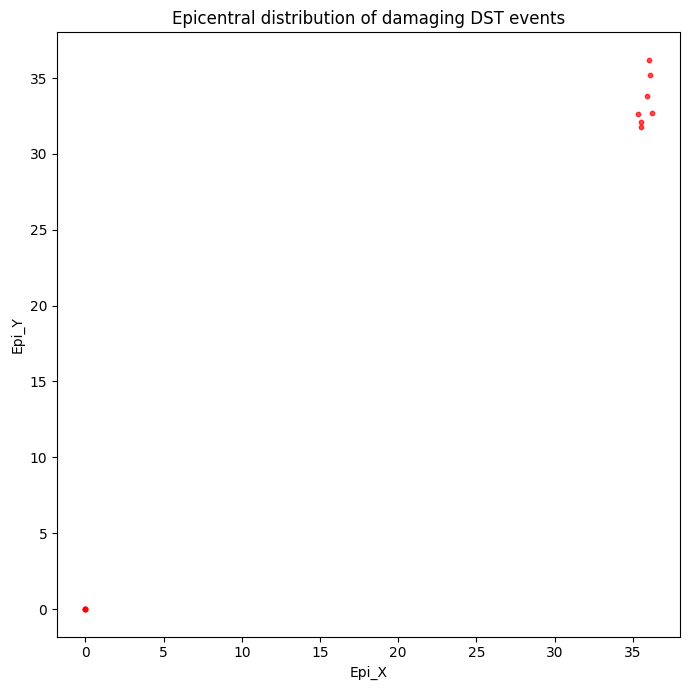

In [68]:
plot_spatial(df, "Epi_X", "Epi_Y", "Epicentral distribution of damaging DST events")


In [69]:
display(numeric_summary(df, ["Magnitude", "Magnitude_Avg", "Max_Intensity", "Depth", "C_Damage", "Max_Damage"]))

,count,mean,std,min,25%,50%,75%,max
Magnitude,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Magnitude_Avg,115.0,5.298957,1.051412,4.5,4.5,4.5,6.15,7.83
Max_Intensity,5.0,7.900000,0.741620,7.0,7.5,8.0,8.00,9.00
Depth,5.0,12.000000,2.738613,10.0,10.0,10.0,15.00,15.00
C_Damage,236.0,5.334746,15.033375,1.0,1.0,2.0,3.00,142.00
Max_Damage,236.0,2.080508,1.460793,-1.0,1.0,2.0,3.00,5.00


## Reliable destructive DST events

**File:** `v_events_dst_reliable_damaging_destructive.csv`

This section summarizes the most destructive reliable DST earthquakes. The focus is on high-impact events, their intensities/magnitudes, temporal clustering, and regional distribution.

In [70]:
file = "v_events_dst_reliable_damaging_destructive.csv"
df = dfs[file]

display(overview_table(df))

,rows,columns,duplicate_rows,total_missing_values,percent_missing_values
0,28,27,0,119,15.74


In [71]:
display(df.head())

,Order_Date,Full_Date,Numeric_Date,Date_Uncertainty,Rel,Type,Size,Size_Val,Magnitude,Magnitude_Avg,Max_Intensity,Depth,Epi_X,Epi_Y,Region,Most_Damaged_Sites,Most_Damaged,MSRD_X,MSRD_Y,Tsunami,GII,Description,Historical_Reports,Ref,Evidence_Type,C_Damage,Max_Damage
0,19,c.760-750 BCE,-760.0,10,High,S,4,Strong,7.8-8.2 (AUS); 8.2 (BM5); 7.3 (BM),7.83,8.0,NaN,NaN,NaN,C,Judaea,Judea (A),35.35,32.08,0,1,Damaging event during mid-8th century BCE. Amo...,Contemporary: Amos 1.1; 3.14-15; 7.13; 9.5\r\n...,AM; GCT; AM2; SAL; SAL2; WALE; BEN; ZIL2; AUS;...,Historical & Paleoseimic/Archaeoseimic,31,4
1,30,c.65 BCE,-65.0,5,Moderate,S,5,Strong-Major,NaN,NaN,9.0,NaN,NaN,NaN,N,Northen Syria,Syria (A),37.03,34.93,0,1,"According to Justin, the earthquake happened d...",Secondary: Pomp. Trog. Apud Iust. Epit. 40.2.1...,AM; GCT; KA2; SAL; SDM; AAT; BM; KEN; AMM; GII...,Historical & Paleoseimic/Archaeoseimic,6,5
2,34,31 early spring BCE,-31.0,1,High,S,5,Strong-Major,6-6.5 (KA2); 6.7 (MIG); 6.7 (BM); 7 (BM5); 7 (...,6.70,NaN,NaN,NaN,NaN,C,Judea,Judea (A),35.35,32.08,0,1,Destructive event in Judea of that time. Josep...,"Near Contemporary: (Josephus, , BeI. 1.369-379...",AM; GCT; KA; KA2; SAL; BR; MZ; AAT; SI; RH; NU...,Historical & Paleoseimic/Archaeoseimic,16,4
3,43,115 Dec 13 (morning),115.0,-,High,MA,6,Major,7.4 (BM5); 7.4 (SDM after BM5),7.40,NaN,NaN,NaN,NaN,N,Antioch,Antakya,36.16,36.20,1,1,"According to reliable sources, the 115 CE eart...","Near Contemporary: Dio Cass. 68.24, 25.6/LCL; ...",AM; GCT; KA; SAL; SAL2; AMJA; SDM; REI; AAT; G...,Historical & Paleoseimic/Archaeoseimic,9,5
4,53,303 Apr 2,303.0,-,High,S,5,Strong-Major,7.1 (BM: Ben-Menahem 1991); 7.1 (MIG: Migowsky...,7.10,NaN,NaN,NaN,NaN,C-N,"Sidon, Tyre, Syria",Syria (A),37.03,34.93,0,1,Damaged mainly the south Lebanese littoral. Eu...,Contemporary: Eus. Mart. Pal. 4.15; \r\nNear C...,AM; GCT; SAL; SAL2; RUS; SDM; GII; WE2,Historical,6,4


In [72]:
display(missing_values_table(df).head(15))

,column,missing_count,missing_percent,dtype
13,Epi_Y,27,96.43,float64
12,Epi_X,27,96.43,float64
11,Depth,27,96.43,float64
10,Max_Intensity,26,92.86,float64
8,Magnitude,5,17.86,object
9,Magnitude_Avg,5,17.86,float64
22,Historical_Reports,1,3.57,object
21,Description,1,3.57,object
2,Numeric_Date,0,0.00,float64
0,Order_Date,0,0.00,int64


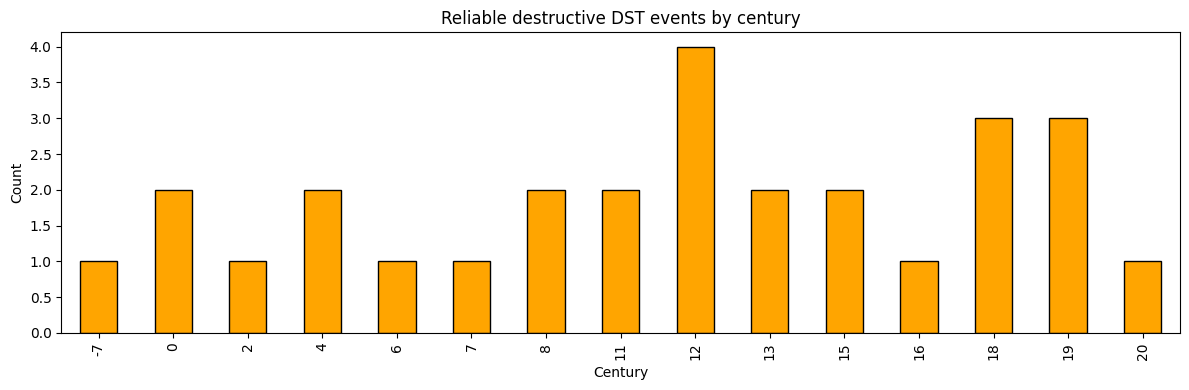

In [73]:
plot_temporal_by_century(df, "Numeric_Date", "Reliable destructive DST events by century")


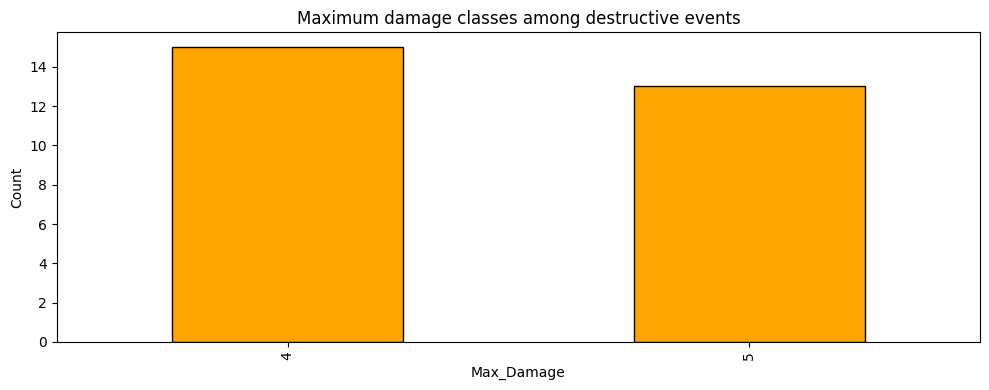

In [74]:
plot_bar_counts(df, "Max_Damage", "Maximum damage classes among destructive events", top_n=20)

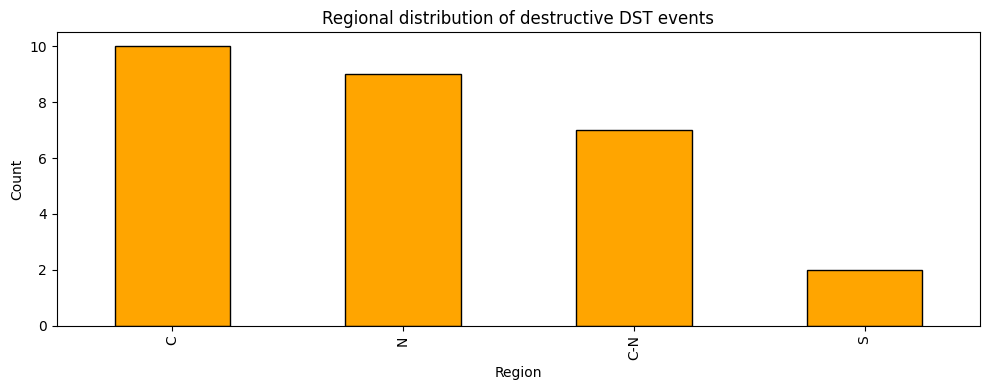

In [75]:
plot_bar_counts(df, "Region", "Regional distribution of destructive DST events", top_n=20)

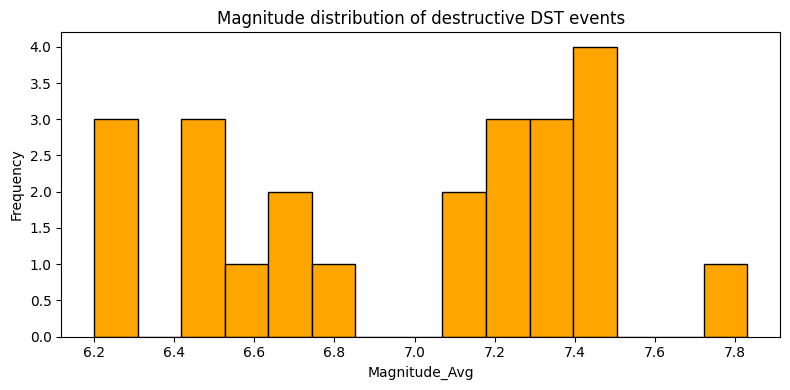

In [76]:
plot_hist(df, "Magnitude_Avg", "Magnitude distribution of destructive DST events", bins=15)

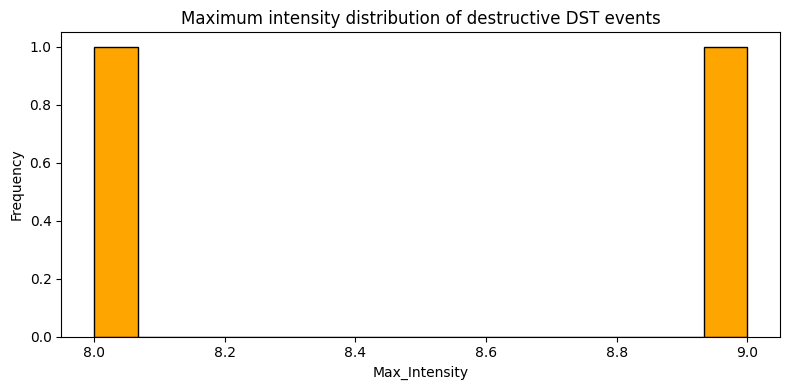

In [77]:
plot_hist(df, "Max_Intensity", "Maximum intensity distribution of destructive DST events", bins=15)

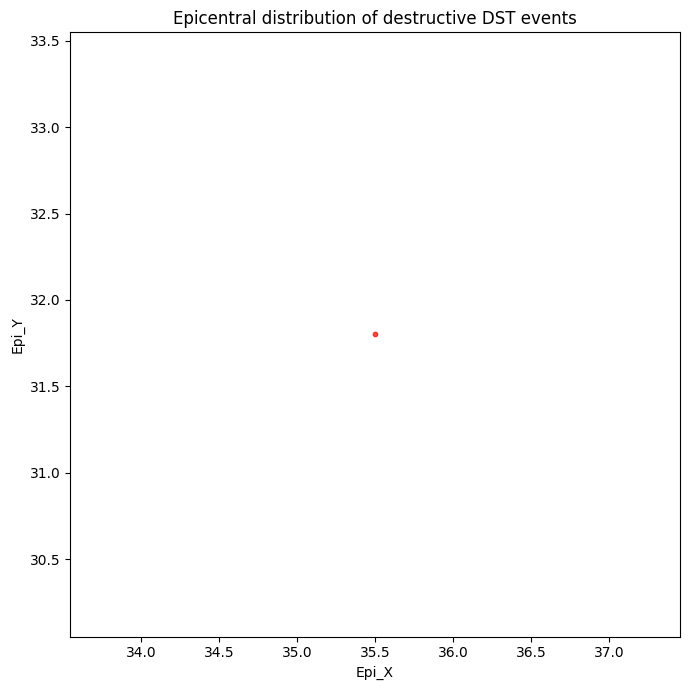

,Full_Date,Numeric_Date,Magnitude_Avg,Max_Intensity,Region,Most_Damaged_Sites,Max_Damage
0,c.760-750 BCE,-760.0,7.83,8.0,C,Judaea,4
6,551 Jul 9,551.0,7.50,NaN,C-N,"Lebanon, Syria, Beirut",4
16,1202 May 20 (0240),1202.0,7.50,NaN,C-N,Baalbek,5
18,1408 Dec 29,1408.0,7.50,NaN,N,Shughr-Bekas,4
3,115 Dec 13 (morning),115.0,7.40,NaN,N,Antioch,5
11,1068 Mar 18,1068.0,7.30,NaN,S,Gulf of Elat,5
15,1170 Jun 29 (0345),1170.0,7.30,NaN,N,Shaizar,5
22,1759 Nov 25 ( 19:23),1759.3,7.30,NaN,C-N,Litany,5
8,c.746 Jan,746.0,7.20,NaN,N,Syria,5
9,749/Early 750,749.0,7.20,NaN,C,Palestine,5


In [78]:
plot_spatial(df, "Epi_X", "Epi_Y", "Epicentral distribution of destructive DST events")
top_cols = [c for c in ["Full_Date", "Numeric_Date", "Magnitude_Avg", "Max_Intensity", "Region", "Most_Damaged_Sites", "Max_Damage"] if c in df.columns]
sort_cols = [c for c in ["Magnitude_Avg", "Max_Intensity"] if c in df.columns]
if sort_cols and top_cols:
    display(df.sort_values(sort_cols, ascending=False).head(10)[top_cols])

## Reliable off-DST events

**File:** `v_events_off_dst_reliable.csv`

This section summarizes reliable earthquakes outside the Dead Sea Transform region that are relevant to the broader eastern Mediterranean context. The focus is on regional comparison, temporal distribution, and magnitude/intensity characteristics.

In [79]:
file = "v_events_off_dst_reliable.csv"
df = dfs[file]

display(overview_table(df))

,rows,columns,duplicate_rows,total_missing_values,percent_missing_values
0,73,25,0,413,22.63


In [80]:
display(df.head())

,Order_Date,Full_Date,Numeric_Date,Date_Uncertainty,Rel,Type,Size,Size_Val,Magnitude,Magnitude_Avg,Max_Intensity,Depth,Epi_X,Epi_Y,Region,Most_Damaged_Sites,Most_Damaged,MSRD_X,MSRD_Y,Tsunami,GII,Description,Historical_Reports,Ref,Evidence_Type
0,-1,Unknown,-10000.0,NaN,Moderate,U,-1,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,U,NaN,Unknown,33.650822,33.051288,NaN,NaN,NaN,NaN,NaN,U
1,-1,Unknown,-10000.0,NaN,Moderate,U,-1,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,U,NaN,Test,NaN,NaN,NaN,NaN,NaN,NaN,NaN,U
2,35,c.20 BCE,-20.0,5,Moderate,S,4,Strong,NaN,NaN,NaN,NaN,NaN,NaN,CA,Pelusium,Pelusium,32.540000,31.040000,1.0,1.0,This event is based upon the evidence of the c...,Contemporary: Str. I. iii. 17/LCL. i. 216; Str...,AM; KA; SAL; SAL2; GII,Historical
3,36,17-15 BCE,-17.0,2,Moderate,S,4,Strong,NaN,NaN,NaN,NaN,NaN,NaN,CA,Cyprus,Cyprus (A),33.100000,34.980000,0.0,1.0,"Dio Cassius, though 3rd century writer is cons...",Secondary: Dio. Cass. 54.23.7; Eus. Hieron. Ch...,AM; GCT; KA; GII,Historical
4,41,76,76.0,1,Moderate,S,4,Strong,NaN,NaN,NaN,NaN,NaN,NaN,CA,Cyprus,Cyprus (A),33.100000,34.980000,1.0,1.0,AM: This earthquake is recorded by secondary b...,Secondary: Eus. Hieron. Chron. 188; Oros. Hist...,AM; GII,Historical


In [81]:
display(missing_values_table(df).head(15))

,column,missing_count,missing_percent,dtype
10,Max_Intensity,73,100.00,float64
11,Depth,60,82.19,float64
12,Epi_X,57,78.08,float64
13,Epi_Y,57,78.08,float64
8,Magnitude,52,71.23,object
9,Magnitude_Avg,42,57.53,float64
22,Historical_Reports,35,47.95,object
21,Description,16,21.92,object
15,Most_Damaged_Sites,8,10.96,object
3,Date_Uncertainty,5,6.85,object


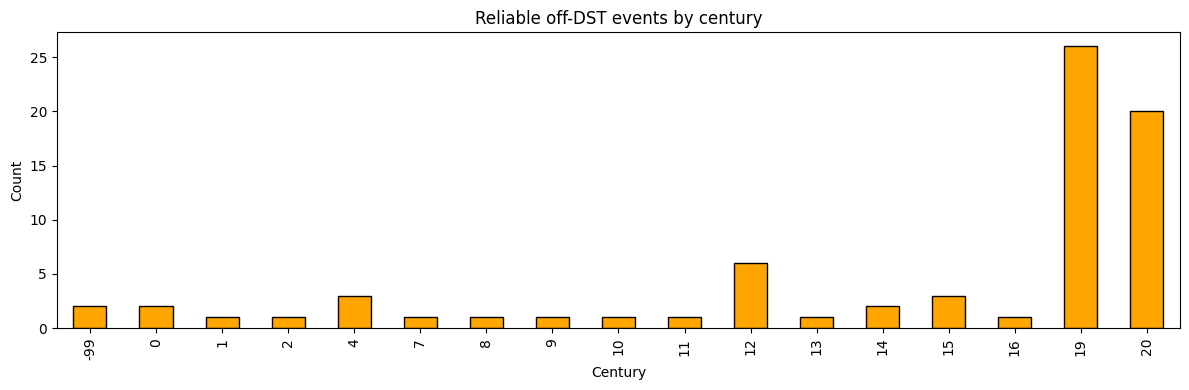

In [82]:
plot_temporal_by_century(df, "Numeric_Date", "Reliable off-DST events by century")


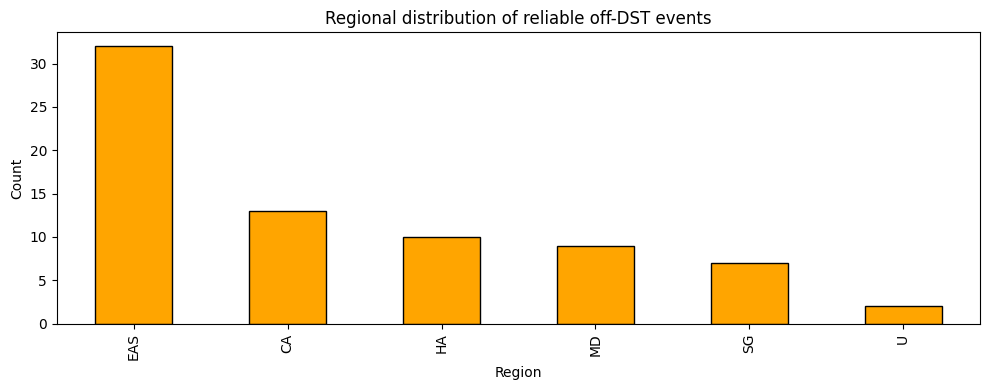

In [83]:
plot_bar_counts(df, "Region", "Regional distribution of reliable off-DST events", top_n=20)

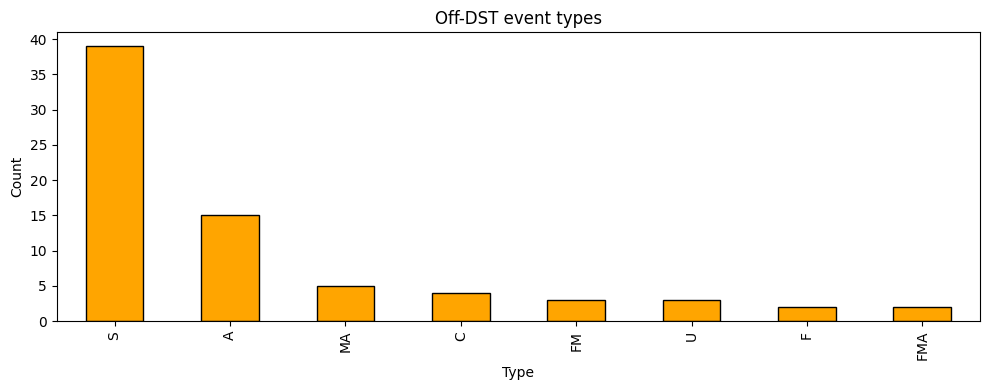

In [84]:
plot_bar_counts(df, "Type", "Off-DST event types", top_n=20)

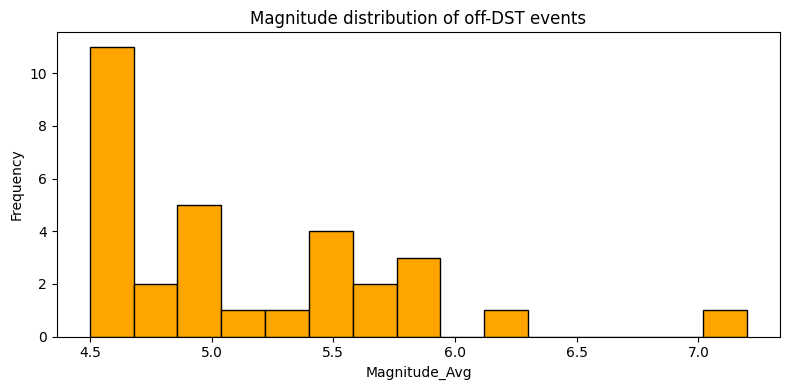

In [85]:
plot_hist(df, "Magnitude_Avg", "Magnitude distribution of off-DST events", bins=15)

In [86]:
plot_hist(df, "Max_Intensity", "Maximum intensity distribution of off-DST events", bins=15)

No numeric values available in Max_Intensity


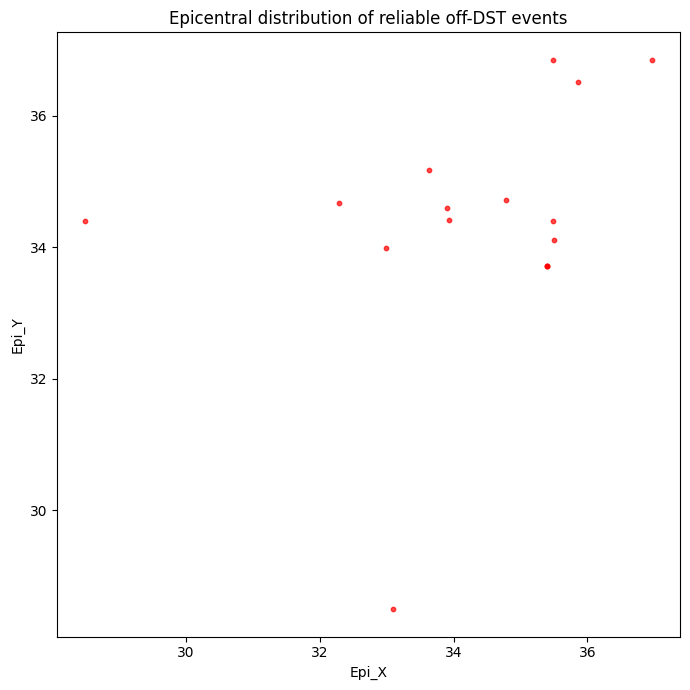

In [87]:
plot_spatial(df, "Epi_X", "Epi_Y", "Epicentral distribution of reliable off-DST events")


In [88]:
display(numeric_summary(df, ["Magnitude", "Magnitude_Avg", "Max_Intensity", "Depth", "Epi_X", "Epi_Y"]))

,count,mean,std,min,25%,50%,75%,max
Magnitude,3.0,5.133333,0.230940,5.0,5.0000,5.000,5.200,5.40
Magnitude_Avg,31.0,5.114516,0.650537,4.5,4.5000,5.000,5.500,7.20
Max_Intensity,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Depth,13.0,12.923077,6.409128,10.0,10.0000,10.000,15.000,33.00
Epi_X,16.0,34.286875,1.985872,28.5,33.4975,35.085,35.490,36.96
Epi_Y,16.0,34.395000,1.892483,28.5,33.9200,34.410,34.835,36.85
